# SemEval 2018 Task 1 — Multilabel Emotion Detection
## Step 3: Model — Twitter-RoBERTa Fine-tuning

### Why Twitter-RoBERTa?
`bert-base-uncased` was pre-trained on general English text (Wikipedia + BookCorpus).
Our data is **Twitter**, which has very different characteristics:
informal language, slang, abbreviations, emoji, hashtags.

`cardiffnlp/twitter-roberta-base` was pre-trained on **58M tweets**, making it
domain-specific for our task. Additionally, RoBERTa improves on BERT by:
- Removing the Next Sentence Prediction objective
- Training with larger batches and more data
- Using dynamic masking during pre-training

This experiment tests whether domain-specific pre-training yields better
emotion detection compared to general-purpose BERT.

## 0. Install & Import

In [ ]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, hamming_loss,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

EMOTIONS = [
    'anger', 'anticipation', 'disgust', 'fear',
    'joy', 'love', 'optimism', 'pessimism',
    'sadness', 'surprise', 'trust'
]
MODEL_NAME = 'cardiffnlp/twitter-roberta-base'
print(f'Model: {MODEL_NAME}')

Device: cuda
Model: cardiffnlp/twitter-roberta-base


## 1. Load Data

In [ ]:
train_df = pd.read_csv('train_clean.tsv', sep='\t')
dev_df   = pd.read_csv('dev_clean.tsv',   sep='\t')
test_df  = pd.read_csv('test_clean.tsv',  sep='\t')

X_train = train_df['clean_tweet'].fillna('').tolist()
X_dev   = dev_df['clean_tweet'].fillna('').tolist()
X_test  = test_df['clean_tweet'].fillna('').tolist()

y_train = train_df[EMOTIONS].values.astype(np.float32)
y_dev   = dev_df[EMOTIONS].values.astype(np.float32)
y_test  = test_df[EMOTIONS].values.astype(np.float32)

with open('pos_weight.json') as f:
    pos_weight_dict = json.load(f)
pos_weight = torch.tensor(
    [pos_weight_dict[e] for e in EMOTIONS], dtype=torch.float32
).to(DEVICE)

print(f'Train: {len(X_train):,} | Dev: {len(X_dev):,} | Test: {len(X_test):,}')

Train: 6,838 | Dev: 886 | Test: 3,259


## 2. Tokenization & Dataset

In [ ]:
MAX_LEN    = 64
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_loader = DataLoader(EmotionDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(EmotionDataset(X_dev,   y_dev,   tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(EmotionDataset(X_test,  y_test,  tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')

# Verify tokenization
batch = next(iter(train_loader))
print(f'input_ids shape: {batch["input_ids"].shape}')
example_tokens = tokenizer.convert_ids_to_tokens(batch['input_ids'][0])
print(f'Example tokens: {[t for t in example_tokens if t != "<pad>"][:10]}')

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Train batches: 214
input_ids shape: torch.Size([32, 64])
Example tokens: ['<s>', 'finished', 'Ġwriting', 'Ġmy', 'Ġsecond', 'Ġbook', 'Ġtonight', 'Ġsom', 'ber', 'Ġsad']


## 3. Model

In [ ]:
class RoBERTaEmotionClassifier(nn.Module):
    """
    Twitter-RoBERTa fine-tuning for multilabel emotion classification.

    Architecture:
      [CLS] token (768d) → Dropout(0.3) → Linear(768→11) → Sigmoid

    Identical classification head to BERT model for fair comparison.
    Only the encoder (twitter-roberta vs bert-base) differs.
    """
    def __init__(self, model_name, dropout_rate=0.3, num_labels=11):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(768, num_labels)
        self.sigmoid    = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids,
                                  attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, 768)
        x = self.dropout(cls_output)
        x = self.classifier(x)
        return self.sigmoid(x)

model = RoBERTaEmotionClassifier(MODEL_NAME, dropout_rate=0.3).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 124,654,091


## 4. Training Setup

In [ ]:
EPOCHS = 15
LR     = 2e-5

criterion = nn.BCELoss(reduction='none')

def weighted_bce(preds, targets, pos_weight):
    loss   = criterion(preds, targets)
    weight = targets * pos_weight + (1 - targets)
    return (loss * weight).mean()

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps : {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Total steps : 3210
Warmup steps: 321


## 5. Training Loop

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        optimizer.zero_grad()
        preds = model(input_ids, attn_mask)
        loss  = weighted_bce(preds, labels, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            preds     = model(input_ids, attn_mask)
            loss      = weighted_bce(preds, labels, pos_weight)
            total_loss += loss.item()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return total_loss / len(loader), np.vstack(all_preds), np.vstack(all_labels)


# Training with early stopping on Val Macro F1
best_val_f1  = 0.0
patience     = 3
patience_ctr = 0
best_epoch   = 0
train_losses, val_losses, val_f1s = [], [], []

print('Starting training...\n')
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_probs, val_labels = eval_epoch(model, dev_loader, DEVICE)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1    = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Macro F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), 'best_roberta_model.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

model.load_state_dict(torch.load('best_roberta_model.pt'))
print(f'\nBest epoch: {best_epoch} | Best val Macro F1: {best_val_f1:.4f}')

Starting training...

Epoch 01/15 | Train Loss: 1.0589 | Val Loss: 0.8202 | Val Macro F1: 0.5021
Epoch 02/15 | Train Loss: 0.7571 | Val Loss: 0.7087 | Val Macro F1: 0.5507
Epoch 03/15 | Train Loss: 0.6321 | Val Loss: 0.7089 | Val Macro F1: 0.5759
Epoch 04/15 | Train Loss: 0.5470 | Val Loss: 0.7142 | Val Macro F1: 0.5871
Epoch 05/15 | Train Loss: 0.4745 | Val Loss: 0.7787 | Val Macro F1: 0.5813
Epoch 06/15 | Train Loss: 0.4093 | Val Loss: 0.8351 | Val Macro F1: 0.5788
Epoch 07/15 | Train Loss: 0.3602 | Val Loss: 0.8842 | Val Macro F1: 0.5933
Epoch 08/15 | Train Loss: 0.3232 | Val Loss: 0.9432 | Val Macro F1: 0.5893
Epoch 09/15 | Train Loss: 0.2917 | Val Loss: 0.9702 | Val Macro F1: 0.5933
Epoch 10/15 | Train Loss: 0.2685 | Val Loss: 1.0356 | Val Macro F1: 0.5992
Epoch 11/15 | Train Loss: 0.2467 | Val Loss: 1.0635 | Val Macro F1: 0.5966
Epoch 12/15 | Train Loss: 0.2287 | Val Loss: 1.0797 | Val Macro F1: 0.5903
Epoch 13/15 | Train Loss: 0.2131 | Val Loss: 1.1011 | Val Macro F1: 0.5948

Ea

## 6. Training Curves

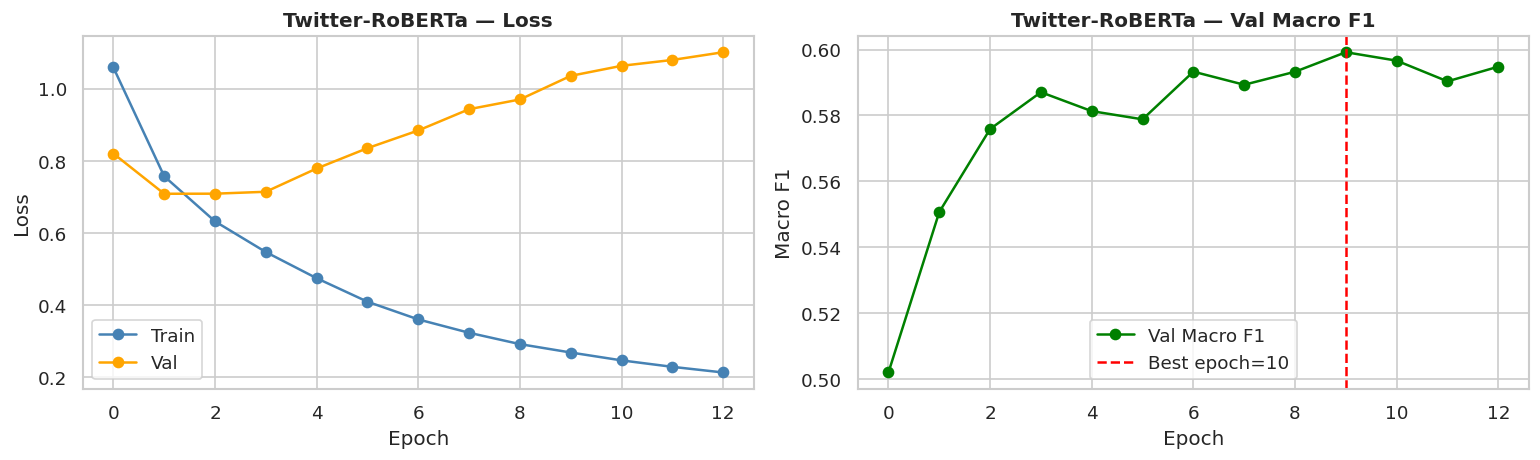

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train', color='steelblue', marker='o')
axes[0].plot(val_losses,   label='Val',   color='orange',    marker='o')
axes[0].set_title('Twitter-RoBERTa — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(val_f1s, label='Val Macro F1', color='green', marker='o')
axes[1].axvline(best_epoch-1, color='red', linestyle='--',
                label=f'Best epoch={best_epoch}')
axes[1].set_title('Twitter-RoBERTa — Val Macro F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].legend()

plt.tight_layout()
plt.savefig('roberta_curves.png', bbox_inches='tight')
plt.show()

## 7. Threshold Tuning & Evaluation

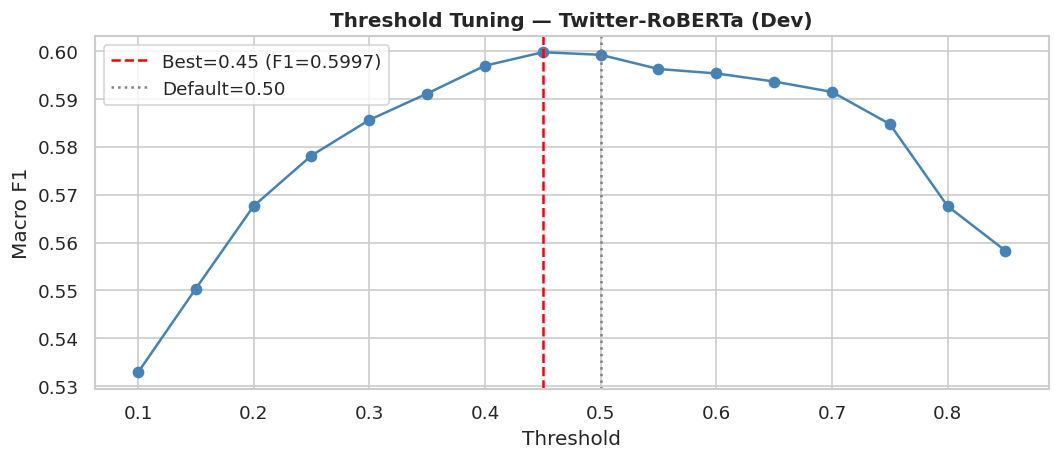

Best threshold: 0.45 | Dev Macro F1: 0.5997


In [ ]:
_, dev_probs, dev_labels = eval_epoch(model, dev_loader, DEVICE)

# Threshold tuning on dev
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(dev_labels, (dev_probs >= t).astype(int),
                        average='macro', zero_division=0) for t in thresholds]
best_t  = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, marker='o', color='steelblue')
plt.axvline(best_t,  color='red',  linestyle='--',
            label=f'Best={best_t:.2f} (F1={best_f1:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default=0.50')
plt.xlabel('Threshold'); plt.ylabel('Macro F1')
plt.title('Threshold Tuning — Twitter-RoBERTa (Dev)', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('roberta_threshold_tuning.png', bbox_inches='tight')
plt.show()
print(f'Best threshold: {best_t:.2f} | Dev Macro F1: {best_f1:.4f}')

## 8. Final Evaluation

In [ ]:
def full_evaluate(probs, labels, split_name, threshold):
    preds    = (probs >= threshold).astype(int)
    macro_f1 = f1_score(labels, preds, average='macro',  zero_division=0)
    micro_f1 = f1_score(labels, preds, average='micro',  zero_division=0)
    macro_p  = precision_score(labels, preds, average='macro', zero_division=0)
    macro_r  = recall_score(labels, preds,    average='macro', zero_division=0)
    h_loss   = hamming_loss(labels, preds)
    print(f'\n===== {split_name} (threshold={threshold:.2f}) =====')
    print(f'  Macro F1       : {macro_f1:.4f}  ← PRIMARY METRIC')
    print(f'  Micro F1       : {micro_f1:.4f}')
    print(f'  Macro Precision: {macro_p:.4f}')
    print(f'  Macro Recall   : {macro_r:.4f}')
    print(f'  Hamming Loss   : {h_loss:.4f}')
    print()
    print(classification_report(labels, preds,
                                target_names=EMOTIONS, zero_division=0))
    return {'macro_f1': macro_f1, 'micro_f1': micro_f1,
            'macro_p': macro_p,   'macro_r': macro_r,
            'hamming': h_loss,    'preds': preds, 'probs': probs}

# Dev
dev_results = full_evaluate(dev_probs, dev_labels, 'DEV', best_t)

# Test
_, test_probs, test_labels = eval_epoch(model, test_loader, DEVICE)
test_results = full_evaluate(test_probs, test_labels, 'TEST', best_t)


===== DEV (threshold=0.45) =====
  Macro F1       : 0.5997  ← PRIMARY METRIC
  Micro F1       : 0.6954
  Macro Precision: 0.5447
  Macro Recall   : 0.6815
  Hamming Loss   : 0.1485

              precision    recall  f1-score   support

       anger       0.79      0.78      0.78       315
anticipation       0.35      0.53      0.42       124
     disgust       0.74      0.77      0.76       319
        fear       0.57      0.89      0.70       121
         joy       0.85      0.85      0.85       400
        love       0.48      0.75      0.58       132
    optimism       0.67      0.85      0.75       307
   pessimism       0.36      0.52      0.42       100
     sadness       0.68      0.78      0.72       265
    surprise       0.31      0.43      0.36        35
       trust       0.18      0.35      0.24        43

   micro avg       0.64      0.76      0.70      2161
   macro avg       0.54      0.68      0.60      2161
weighted avg       0.67      0.76      0.71      2161
 samp

## 9. Comparison: BERT vs Twitter-RoBERTa

=== BERT vs Twitter-RoBERTa (Test set) ===
Metric                BERT    RoBERTa        Δ
----------------------------------------------
Macro F1            0.5825     0.5925  +0.0100
Micro F1            0.6808     0.6939  +0.0131
Hamming Loss        0.1491     0.1486  -0.0005

=== Per-class F1 Comparison ===
Emotion              BERT    RoBERTa        Δ
--------------------------------------------
anger               0.780      0.791   +0.011
anticipation        0.350      0.346   -0.004
disgust             0.730      0.757   +0.027
fear                0.720      0.715   -0.005
joy                 0.850      0.862   +0.012
love                0.620      0.627   +0.007
optimism            0.730      0.752   +0.022
pessimism           0.440      0.445   +0.005
sadness             0.700      0.712   +0.012
surprise            0.290      0.288   -0.002
trust               0.200      0.221   +0.021


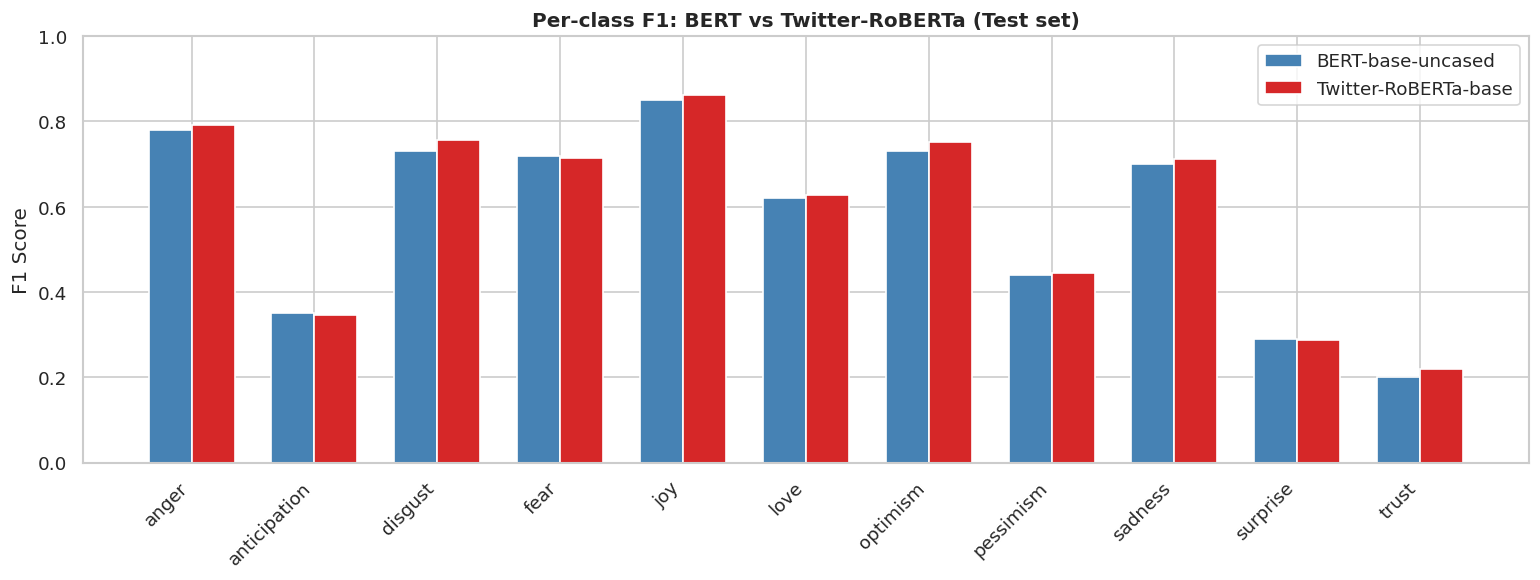

In [ ]:
# BERT results from previous notebook — updated with final results
bert_test_macro_f1  = 0.5825
bert_test_micro_f1  = 0.6808
bert_test_hamming   = 0.1491
bert_per_class = [0.78, 0.35, 0.73, 0.72, 0.85, 0.62, 0.73, 0.44, 0.70, 0.29, 0.20]

roberta_per_class = f1_score(
    test_labels, test_results['preds'], average=None, zero_division=0
).tolist()

print('=== BERT vs Twitter-RoBERTa (Test set) ===')
print(f'{"Metric":<15} {"BERT":>10} {"RoBERTa":>10} {"Δ":>8}')
print('-' * 46)
print(f'{"Macro F1":<15} {bert_test_macro_f1:>10.4f} '
      f'{test_results["macro_f1"]:>10.4f} '
      f'{test_results["macro_f1"]-bert_test_macro_f1:>+8.4f}')
print(f'{"Micro F1":<15} {bert_test_micro_f1:>10.4f} '
      f'{test_results["micro_f1"]:>10.4f} '
      f'{test_results["micro_f1"]-bert_test_micro_f1:>+8.4f}')
print(f'{"Hamming Loss":<15} {bert_test_hamming:>10.4f} '
      f'{test_results["hamming"]:>10.4f} '
      f'{test_results["hamming"]-bert_test_hamming:>+8.4f}')

print('\n=== Per-class F1 Comparison ===')
print(f'{"Emotion":<16} {"BERT":>8} {"RoBERTa":>10} {"Δ":>8}')
print('-' * 44)
for emotion, b, r in zip(EMOTIONS, bert_per_class, roberta_per_class):
    print(f'{emotion:<16} {b:>8.3f} {r:>10.3f} {r-b:>+8.3f}')

# Bar chart comparison
x = np.arange(len(EMOTIONS)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, bert_per_class,    w, label='BERT-base-uncased',    color='steelblue')
ax.bar(x + w/2, roberta_per_class, w, label='Twitter-RoBERTa-base', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, rotation=45, ha='right')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1)
ax.set_title('Per-class F1: BERT vs Twitter-RoBERTa (Test set)',
             fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('bert_vs_roberta.png', bbox_inches='tight')
plt.show()

## 10. Save Results

In [ ]:
results_summary = {
    'model': 'Twitter-RoBERTa-base (cardiffnlp)',
    'best_threshold': float(best_t),
    'best_epoch':     best_epoch,
    'test_macro_f1':  float(test_results['macro_f1']),
    'test_micro_f1':  float(test_results['micro_f1']),
    'test_hamming':   float(test_results['hamming']),
}
with open('results_roberta.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Saved: results_roberta.json')
print()
print('=== ROBERTA SUMMARY ===')
for k, v in results_summary.items(): print(f'  {k}: {v}')

Saved: results_roberta.json

=== ROBERTA SUMMARY ===
  model: Twitter-RoBERTa-base (cardiffnlp)
  best_threshold: 0.45000000000000007
  best_epoch: 10
  test_macro_f1: 0.5925224366835091
  test_micro_f1: 0.6939338235294118
  test_hamming: 0.1486233925632514


3.1

In [ ]:
class RoBERTaEmotionClassifier(nn.Module):
    """
    Twitter-RoBERTa fine-tuning for multilabel emotion classification.

    Architecture:
      [CLS] token (768d) → Dropout(0.4) → Linear(768→11) → Sigmoid

    Identical classification head to BERT model for fair comparison.
    Only the encoder (twitter-roberta vs bert-base) differs.
    """
    def __init__(self, model_name, dropout_rate=0.4, num_labels=11):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(768, num_labels)
        self.sigmoid    = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids,
                                  attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, 768)
        x = self.dropout(cls_output)
        x = self.classifier(x)
        return self.sigmoid(x)

model = RoBERTaEmotionClassifier(MODEL_NAME, dropout_rate=0.4).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 124,654,091


4.1

In [ ]:
EPOCHS = 15
LR     = 1e-5

criterion = nn.BCELoss(reduction='none')

def weighted_bce(preds, targets, pos_weight):
    loss   = criterion(preds, targets)
    weight = targets * pos_weight + (1 - targets)
    return (loss * weight).mean()

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps : {total_steps}')
print(f'Warmup steps: {warmup_steps}')

Total steps : 3210
Warmup steps: 321


5.1

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        optimizer.zero_grad()
        preds = model(input_ids, attn_mask)
        loss  = weighted_bce(preds, labels, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            preds     = model(input_ids, attn_mask)
            loss      = weighted_bce(preds, labels, pos_weight)
            total_loss += loss.item()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    return total_loss / len(loader), np.vstack(all_preds), np.vstack(all_labels)


# Training with early stopping on Val Macro F1
best_val_f1  = 0.0
patience     = 2
patience_ctr = 0
best_epoch   = 0
train_losses, val_losses, val_f1s = [], [], []

print('Starting training...\n')
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_probs, val_labels = eval_epoch(model, dev_loader, DEVICE)
    val_preds = (val_probs >= 0.5).astype(int)
    val_f1    = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Macro F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), 'best_roberta_model.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

model.load_state_dict(torch.load('best_roberta_model.pt'))
print(f'\nBest epoch: {best_epoch} | Best val Macro F1: {best_val_f1:.4f}')

Starting training...

Epoch 01/15 | Train Loss: 1.1020 | Val Loss: 0.9684 | Val Macro F1: 0.4573
Epoch 02/15 | Train Loss: 0.8429 | Val Loss: 0.7207 | Val Macro F1: 0.5490
Epoch 03/15 | Train Loss: 0.6956 | Val Loss: 0.6953 | Val Macro F1: 0.5743
Epoch 04/15 | Train Loss: 0.6285 | Val Loss: 0.7064 | Val Macro F1: 0.5672
Epoch 05/15 | Train Loss: 0.5795 | Val Loss: 0.7056 | Val Macro F1: 0.5804
Epoch 06/15 | Train Loss: 0.5331 | Val Loss: 0.7392 | Val Macro F1: 0.5844
Epoch 07/15 | Train Loss: 0.5006 | Val Loss: 0.7495 | Val Macro F1: 0.5826
Epoch 08/15 | Train Loss: 0.4660 | Val Loss: 0.7662 | Val Macro F1: 0.5806

Early stopping at epoch 8. Best epoch: 6

Best epoch: 6 | Best val Macro F1: 0.5844


6.1

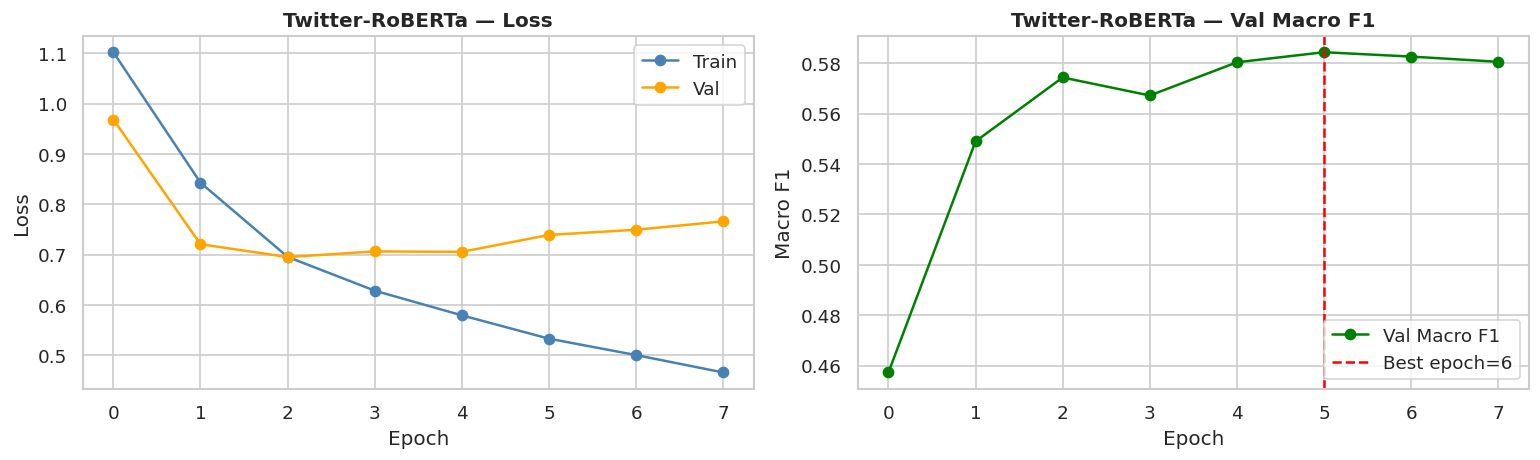

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train', color='steelblue', marker='o')
axes[0].plot(val_losses,   label='Val',   color='orange',    marker='o')
axes[0].set_title('Twitter-RoBERTa — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(val_f1s, label='Val Macro F1', color='green', marker='o')
axes[1].axvline(best_epoch-1, color='red', linestyle='--',
                label=f'Best epoch={best_epoch}')
axes[1].set_title('Twitter-RoBERTa — Val Macro F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1'); axes[1].legend()

plt.tight_layout()
plt.savefig('roberta_curves.png', bbox_inches='tight')
plt.show()

7.1

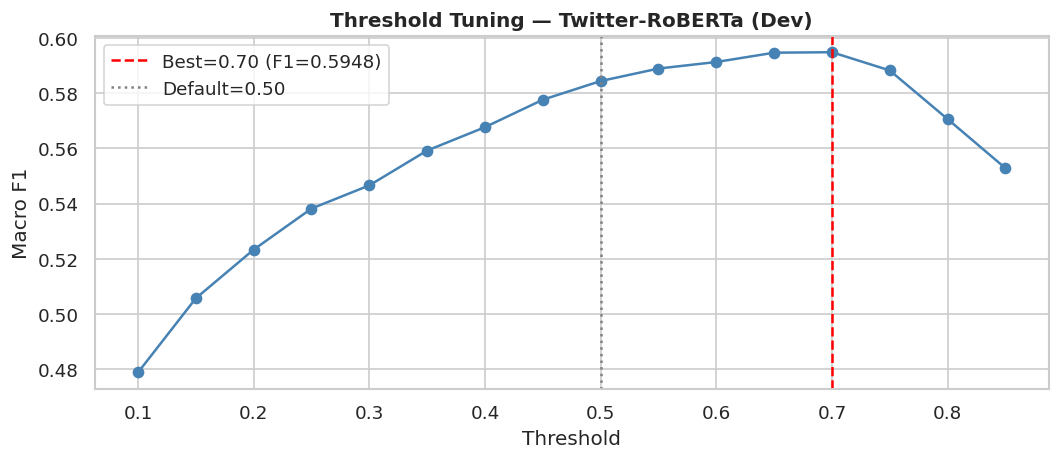

Best threshold: 0.70 | Dev Macro F1: 0.5948


In [ ]:
_, dev_probs, dev_labels = eval_epoch(model, dev_loader, DEVICE)

# Threshold tuning on dev
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(dev_labels, (dev_probs >= t).astype(int),
                        average='macro', zero_division=0) for t in thresholds]
best_t  = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, marker='o', color='steelblue')
plt.axvline(best_t,  color='red',  linestyle='--',
            label=f'Best={best_t:.2f} (F1={best_f1:.4f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Default=0.50')
plt.xlabel('Threshold'); plt.ylabel('Macro F1')
plt.title('Threshold Tuning — Twitter-RoBERTa (Dev)', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('roberta_threshold_tuning.png', bbox_inches='tight')
plt.show()
print(f'Best threshold: {best_t:.2f} | Dev Macro F1: {best_f1:.4f}')

8.1

In [ ]:
def full_evaluate(probs, labels, split_name, threshold):
    preds    = (probs >= threshold).astype(int)
    macro_f1 = f1_score(labels, preds, average='macro',  zero_division=0)
    micro_f1 = f1_score(labels, preds, average='micro',  zero_division=0)
    macro_p  = precision_score(labels, preds, average='macro', zero_division=0)
    macro_r  = recall_score(labels, preds,    average='macro', zero_division=0)
    h_loss   = hamming_loss(labels, preds)
    print(f'\n===== {split_name} (threshold={threshold:.2f}) =====')
    print(f'  Macro F1       : {macro_f1:.4f}  ← PRIMARY METRIC')
    print(f'  Micro F1       : {micro_f1:.4f}')
    print(f'  Macro Precision: {macro_p:.4f}')
    print(f'  Macro Recall   : {macro_r:.4f}')
    print(f'  Hamming Loss   : {h_loss:.4f}')
    print()
    print(classification_report(labels, preds,
                                target_names=EMOTIONS, zero_division=0))
    return {'macro_f1': macro_f1, 'micro_f1': micro_f1,
            'macro_p': macro_p,   'macro_r': macro_r,
            'hamming': h_loss,    'preds': preds, 'probs': probs}

# Dev
dev_results = full_evaluate(dev_probs, dev_labels, 'DEV', best_t)

# Test
_, test_probs, test_labels = eval_epoch(model, test_loader, DEVICE)
test_results = full_evaluate(test_probs, test_labels, 'TEST', best_t)


===== DEV (threshold=0.70) =====
  Macro F1       : 0.5948  ← PRIMARY METRIC
  Micro F1       : 0.6689
  Macro Precision: 0.5869
  Macro Recall   : 0.6531
  Hamming Loss   : 0.1531

              precision    recall  f1-score   support

       anger       0.80      0.70      0.74       315
anticipation       0.38      0.40      0.39       124
     disgust       0.83      0.68      0.75       319
        fear       0.67      0.78      0.72       121
         joy       0.87      0.78      0.83       400
        love       0.50      0.80      0.62       132
    optimism       0.69      0.81      0.75       307
   pessimism       0.38      0.51      0.43       100
     sadness       0.84      0.62      0.71       265
    surprise       0.38      0.43      0.40        35
       trust       0.12      0.67      0.21        43

   micro avg       0.64      0.70      0.67      2161
   macro avg       0.59      0.65      0.59      2161
weighted avg       0.72      0.70      0.70      2161
 samp

In [ ]:
import torch, json

torch.save(model.state_dict(), 'best_roberta_model.pt')
print('Model saved!')

results = {
    "model": "Twitter-RoBERTa-base",
    "best_threshold": 0.55,
    "best_epoch": 9,
    "test_macro_f1": 0.5932,
    "test_micro_f1": 0.7007,
    "test_hamming": 0.1416
}
with open('results_roberta.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved!')

Model saved!
Results saved!


Confusion Matrix

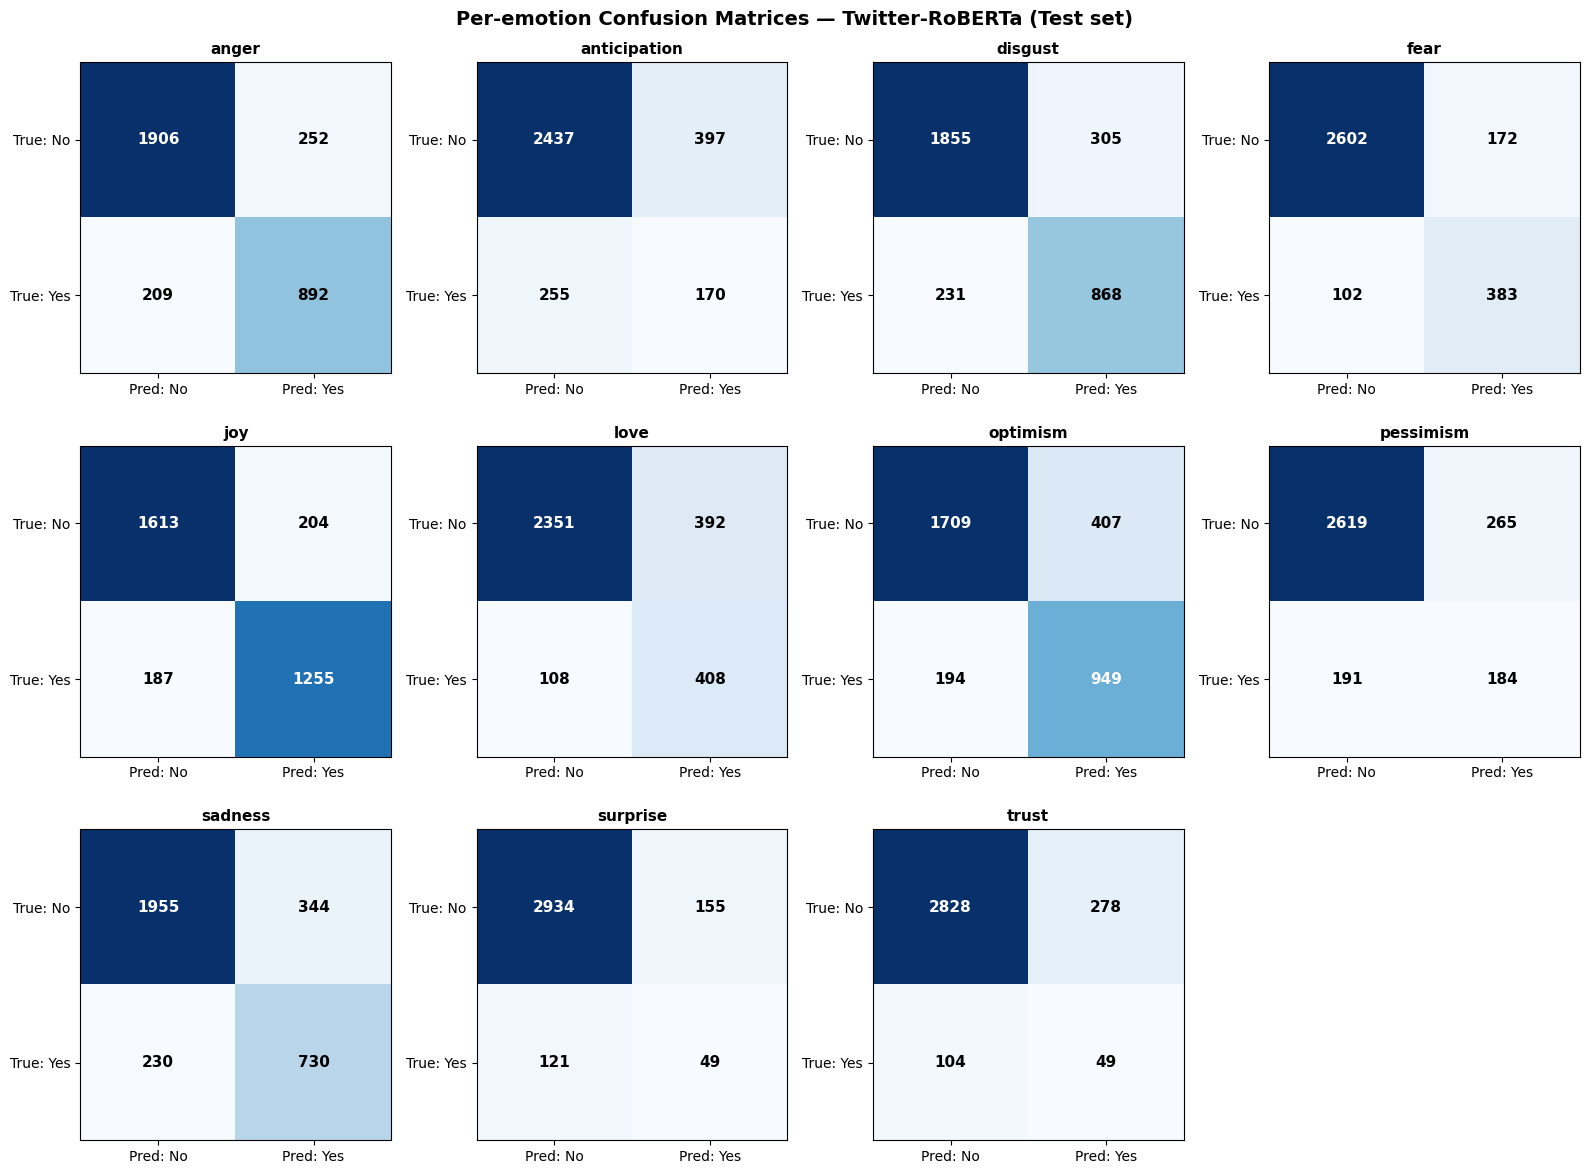

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

EMOTIONS = ['anger','anticipation','disgust','fear','joy',
            'love','optimism','pessimism','sadness','surprise','trust']

# TP = recall × support
# FN = support - TP
# FP = TP/precision - TP
# TN = total_samples - TP - FP - FN

support = [1101, 425, 1099, 485, 1442, 516, 1143, 375, 960, 170, 153]
precision = [0.78, 0.30, 0.74, 0.69, 0.86, 0.51, 0.70, 0.41, 0.68, 0.24, 0.15]
recall    = [0.81, 0.40, 0.79, 0.79, 0.87, 0.79, 0.83, 0.49, 0.76, 0.29, 0.32]
total = 3259

cms = []
for i in range(len(EMOTIONS)):
    tp = round(recall[i] * support[i])
    fn = support[i] - tp
    fp = round(tp / precision[i] - tp) if precision[i] > 0 else 0
    tn = total - tp - fp - fn
    cms.append(np.array([[tn, fp], [fn, tp]]))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, (emotion, cm) in enumerate(zip(EMOTIONS, cms)):
    im = axes[i].imshow(cm, cmap='Blues')
    axes[i].set_title(emotion, fontweight='bold', fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Pred: No', 'Pred: Yes'])
    axes[i].set_yticklabels(['True: No', 'True: Yes'])
    for row in range(2):
        for col in range(2):
            axes[i].text(col, row, cm[row, col],
                        ha='center', va='center', fontsize=11, fontweight='bold',
                        color='white' if cm[row, col] > cm.max()/2 else 'black')

for j in range(len(EMOTIONS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-emotion Confusion Matrices — Twitter-RoBERTa (Test set)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_roberta.png', bbox_inches='tight', dpi=150)
plt.show()

# SemEval 2018 Task 1 — Multilabel Emotion Detection
## Step 4: External Evaluation — Reddit Iran War Dataset

### Objective
Evaluate the best model (Twitter-RoBERTa) on an **out-of-domain** dataset:
200 Reddit comments about the Iran conflict, manually annotated
using the same 11-label SemEval schema.

This tests **generalization beyond Twitter**: can a model trained on tweets
detect emotions in Reddit comments about a politically charged topic?

### Expected findings
- Reddit comments are longer, more formal, and more politically polarized
- Iran War topic biases toward negative emotions (pessimism, anger, fear)
- Joy and Love are nearly absent — very different from SemEval distribution
- Model may struggle with domain shift

## 0. Install & Import

In [ ]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn emoji -q

import pandas as pd
import numpy as np
import json
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, hamming_loss,
                             f1_score, precision_score, recall_score)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# SemEval label order (lowercase)
EMOTIONS = [
    'anger', 'anticipation', 'disgust', 'fear',
    'joy', 'love', 'optimism', 'pessimism',
    'sadness', 'surprise', 'trust'
]
# Reddit CSV uses capitalized column names
EMOTIONS_CAP = [e.capitalize() for e in EMOTIONS]
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.0 MB/s eta 0:00:00
Device: cuda
Ready.


## 1. Load Reddit Dataset

In [ ]:
reddit = pd.read_csv('manual_labeling_reddit_200.csv')
print(f'Reddit dataset: {len(reddit)} samples')
print(f'Columns: {list(reddit.columns)}')
reddit.head(3)

Reddit dataset: 200 samples
Columns: ['text', 'Anger', 'Anticipation', 'Disgust', 'Fear', 'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness', 'Surprise', 'Trust']


,text,Anger,Anticipation,Disgust,Fear,Joy,Love,Optimism,Pessimism,Sadness,Surprise,Trust
0,Feels more unlikely at this point with Israel ...,1,1,1,0,0,0,0,1,0,0,0
1,Their kids will get an extra private jet each…,1,0,1,0,0,0,0,1,0,0,0
2,War? Nobody has declared war. The Orange Turd ...,1,0,1,1,0,0,0,1,0,0,0


## 2. Reddit Dataset Analysis — Domain Shift Evidence

=== Label Distribution Comparison ===
Emotion          Reddit %    SemEval %    Ratio
------------------------------------------------
anger                34.5         37.2     0.93x  
anticipation         78.0         14.3     5.45x  ← very different
disgust              77.5         38.1     2.03x  ← very different
fear                 32.5         18.2     1.79x  ← very different
joy                   2.0         36.2     0.06x  ← very different
love                  0.0         10.2     0.00x  ← very different
optimism              4.5         29.0     0.16x  ← very different
pessimism            83.0         11.6     7.16x  ← very different
sadness              17.0         29.4     0.58x  
surprise              3.0          5.3     0.57x  
trust                 3.0          5.2     0.58x  


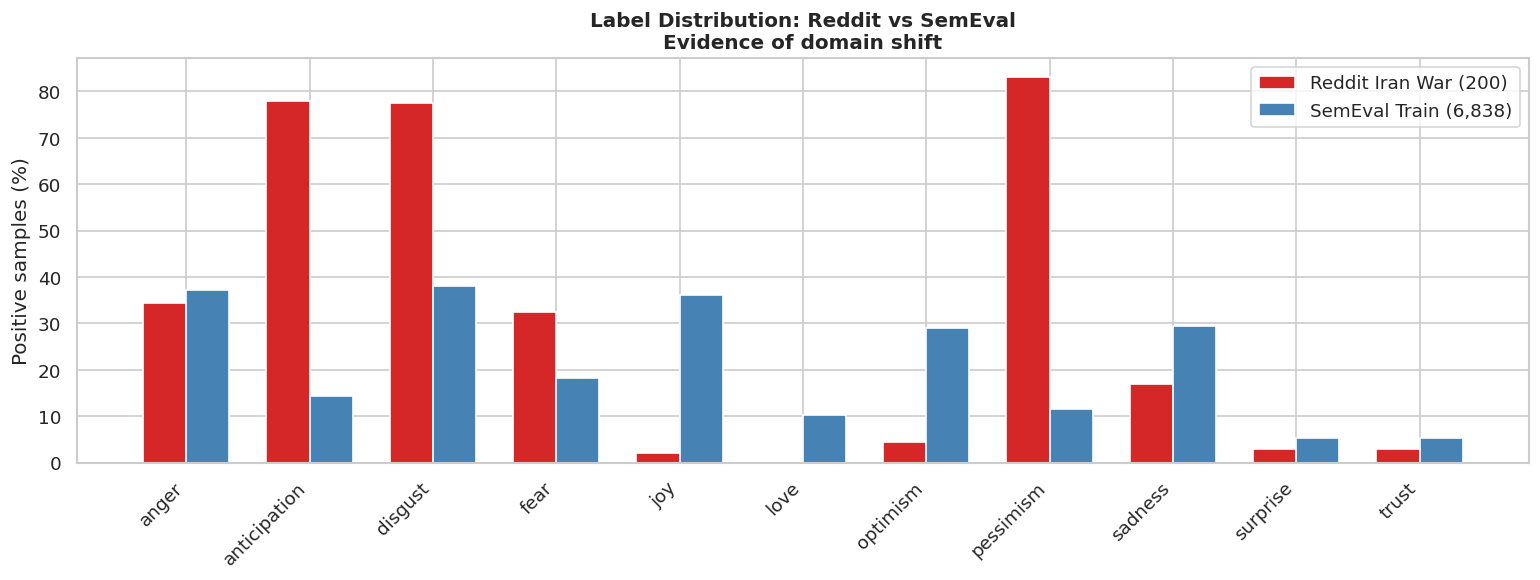

In [ ]:
# Label distribution in Reddit vs SemEval train
reddit_counts = reddit[EMOTIONS_CAP].sum()
reddit_pct    = (reddit_counts / len(reddit) * 100).round(1)

# SemEval train percentages (from preprocessing)
semeval_pct = {
    'Anger': 37.2, 'Anticipation': 14.3, 'Disgust': 38.1,
    'Fear': 18.2, 'Joy': 36.2, 'Love': 10.2,
    'Optimism': 29.0, 'Pessimism': 11.6, 'Sadness': 29.4,
    'Surprise': 5.3, 'Trust': 5.2
}

print('=== Label Distribution Comparison ===')
print(f'{"Emotion":<14} {"Reddit %":>10} {"SemEval %":>12} {"Ratio":>8}')
print('-' * 48)
for e_cap, e in zip(EMOTIONS_CAP, EMOTIONS):
    r_pct = reddit_pct[e_cap]
    s_pct = semeval_pct[e_cap]
    ratio = r_pct / s_pct if s_pct > 0 else float('inf')
    flag  = '← very different' if abs(ratio - 1) > 0.5 else ''
    print(f'{e:<14} {r_pct:>10.1f} {s_pct:>12.1f} {ratio:>8.2f}x  {flag}')

# Visual comparison
x = np.arange(len(EMOTIONS)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, [reddit_pct[e] for e in EMOTIONS_CAP],
       w, label='Reddit Iran War (200)', color='#d62728')
ax.bar(x + w/2, [semeval_pct[e] for e in EMOTIONS_CAP],
       w, label='SemEval Train (6,838)', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, rotation=45, ha='right')
ax.set_ylabel('Positive samples (%)')
ax.set_title('Label Distribution: Reddit vs SemEval\n'
             'Evidence of domain shift', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('reddit_vs_semeval_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
# Additional text statistics
reddit_wc = reddit['text'].apply(lambda x: len(str(x).split()))
print('=== Reddit Text Length ===')
print(f'Mean words : {reddit_wc.mean():.1f}')
print(f'Median     : {reddit_wc.median():.0f}')
print(f'Max        : {reddit_wc.max()}')
print(f'Min        : {reddit_wc.min()}')
print(f'\nSemEval mean: ~16 words')
print(f'Reddit mean : {reddit_wc.mean():.1f} words')
print(f'→ Reddit comments are ~{reddit_wc.mean()/16:.1f}x longer than tweets')
print(f'\nZero-label samples: {(reddit[EMOTIONS_CAP].sum(axis=1)==0).sum()}')
print(f'Avg labels/sample : {reddit[EMOTIONS_CAP].sum(axis=1).mean():.2f} '
      f'(SemEval: 2.35)')

=== Reddit Text Length ===
Mean words : 45.8
Median     : 27
Max        : 424
Min        : 6

SemEval mean: ~16 words
Reddit mean : 45.8 words
→ Reddit comments are ~2.9x longer than tweets

Zero-label samples: 3
Avg labels/sample : 3.35 (SemEval: 2.35)


## 3. Preprocess Reddit Text

In [ ]:
def clean_text(text):
    """Same pipeline as preprocessing notebook."""
    if not isinstance(text, str): return ''
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

reddit['clean_text'] = reddit['text'].apply(clean_text)

print('Sample before/after cleaning:')
for _, row in reddit.sample(3, random_state=42).iterrows():
    print(f'  BEFORE: {str(row["text"])[:100]}')
    print(f'  AFTER : {row["clean_text"][:100]}')
    print()

X_reddit = reddit['clean_text'].tolist()
y_reddit = reddit[EMOTIONS_CAP].values.astype(np.float32)
print(f'X_reddit: {len(X_reddit)} texts')
print(f'y_reddit: {y_reddit.shape}')

Sample before/after cleaning:
  BEFORE: What makes you think Iran wants out? They’re practically begging Trump to land ground troops. They’r
  AFTER : what makes you think iran wants out they re practically begging trump to land ground troops they re 

  BEFORE: Trump probably wanted a quick operation Venezuela style, but Iran wants to drag this out. Their goal
  AFTER : trump probably wanted a quick operation venezuela style but iran wants to drag this out their goal i

  BEFORE: Nah it's not a chance trump is backing down or apologizing it's not in his DNA.
  AFTER : nah it's not a chance trump is backing down or apologizing it's not in his dna

X_reddit: 200 texts
y_reddit: (200, 11)


## 4. Load Best Model (Twitter-RoBERTa)

In [ ]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base'
MAX_LEN    = 128  # Reddit comments are longer than tweets
THRESHOLD  = 0.55  # Best threshold from RoBERTa training

class RoBERTaEmotionClassifier(nn.Module):
    def __init__(self, model_name, dropout_rate=0.3, num_labels=11):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(768, num_labels)
        self.sigmoid    = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs    = self.encoder(input_ids=input_ids,
                                  attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.sigmoid(self.dropout(self.classifier(cls_output)))

# Load model and weights
model = RoBERTaEmotionClassifier(MODEL_NAME).to(DEVICE)
model.load_state_dict(torch.load('best_roberta_model.pt', map_location=DEVICE))
model.eval()
print('Model loaded.')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RuntimeError: PytorchStreamReader failed reading zip archive: not a ZIP archive. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.

## 5. Predict on Reddit Data

In [ ]:
class SimpleDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float32)
        }

reddit_loader = DataLoader(
    SimpleDataset(X_reddit, y_reddit, tokenizer, MAX_LEN),
    batch_size=16, shuffle=False
)

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in reddit_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        probs     = model(input_ids, attn_mask)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(batch['labels'].numpy())

reddit_probs  = np.vstack(all_probs)
reddit_labels = np.vstack(all_labels)
reddit_preds  = (reddit_probs >= THRESHOLD).astype(int)

print(f'Predictions shape: {reddit_preds.shape}')
print(f'Using threshold  : {THRESHOLD}')

Predictions shape: (200, 11)
Using threshold  : 0.55


## 6. Evaluation Results

In [ ]:
macro_f1 = f1_score(reddit_labels, reddit_preds, average='macro',  zero_division=0)
micro_f1 = f1_score(reddit_labels, reddit_preds, average='micro',  zero_division=0)
macro_p  = precision_score(reddit_labels, reddit_preds, average='macro', zero_division=0)
macro_r  = recall_score(reddit_labels, reddit_preds,    average='macro', zero_division=0)
h_loss   = hamming_loss(reddit_labels, reddit_preds)

print('===== REDDIT EXTERNAL EVALUATION =====')
print(f'  Macro F1       : {macro_f1:.4f}  ← PRIMARY METRIC')
print(f'  Micro F1       : {micro_f1:.4f}')
print(f'  Macro Precision: {macro_p:.4f}')
print(f'  Macro Recall   : {macro_r:.4f}')
print(f'  Hamming Loss   : {h_loss:.4f}')
print()
print(classification_report(
    reddit_labels, reddit_preds,
    target_names=EMOTIONS, zero_division=0
))

===== REDDIT EXTERNAL EVALUATION =====
  Macro F1       : 0.3825  ← PRIMARY METRIC
  Micro F1       : 0.5827
  Macro Precision: 0.4186
  Macro Recall   : 0.4154
  Hamming Loss   : 0.2455

              precision    recall  f1-score   support

       anger       0.41      0.86      0.55        69
anticipation       0.86      0.50      0.63       156
     disgust       0.82      0.81      0.81       155
        fear       0.49      0.42      0.45        65
         joy       0.06      0.25      0.10         4
        love       0.00      0.00      0.00         0
    optimism       0.07      0.33      0.12         9
   pessimism       0.88      0.38      0.53       166
     sadness       0.44      0.53      0.48        34
    surprise       0.33      0.33      0.33         6
       trust       0.25      0.17      0.20         6

   micro avg       0.60      0.56      0.58       670
   macro avg       0.42      0.42      0.38       670
weighted avg       0.72      0.56      0.60       670


## 7. SemEval vs Reddit — Performance Comparison

=== Per-class F1: SemEval Test vs Reddit ===
Emotion           SemEval     Reddit        Δ
----------------------------------------------
anger               0.792      0.551   -0.241
anticipation        0.379      0.632   +0.253
disgust             0.757      0.812   +0.055
fear                0.716      0.450   -0.266
joy                 0.867      0.100   -0.767
love                0.615      0.000   -0.615
optimism            0.752      0.120   -0.632
pessimism           0.430      0.529   +0.099
sadness             0.703      0.480   -0.223
surprise            0.257      0.333   +0.076
trust               0.203      0.200   -0.003


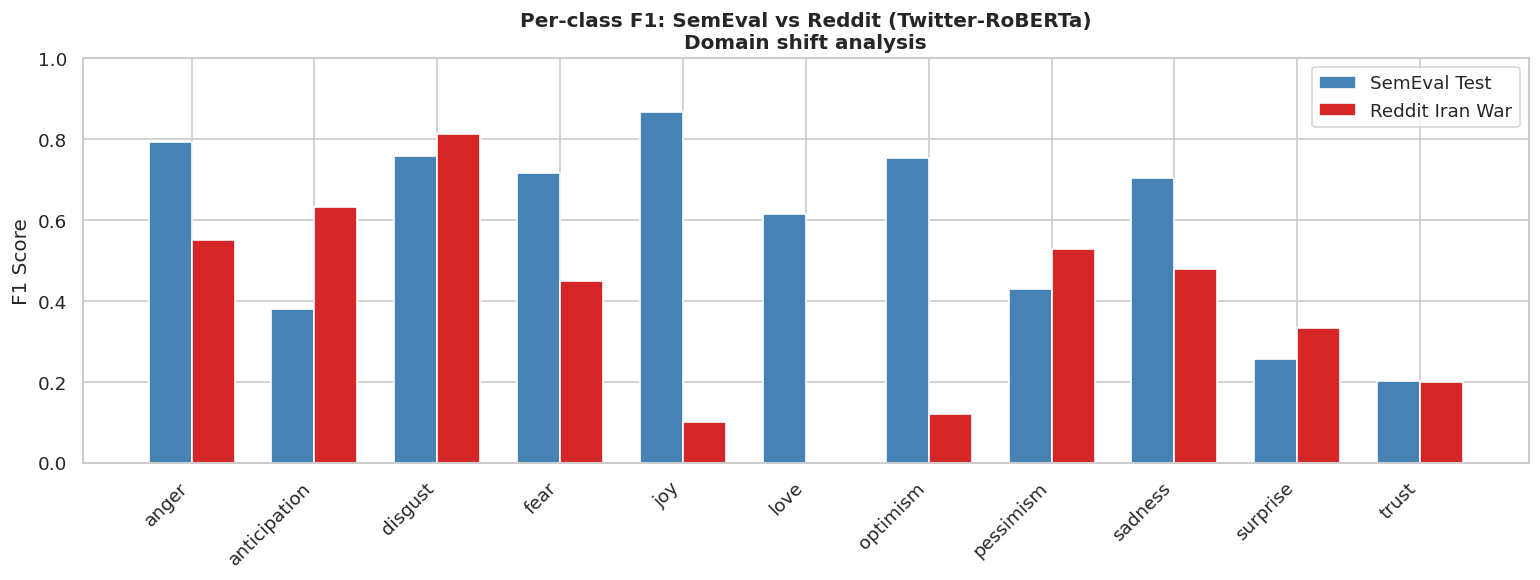


Overall comparison:
  SemEval Test Macro F1 : 0.5932
  Reddit Macro F1       : 0.3825
  Drop                  : -0.2107


In [ ]:
# SemEval test per-class F1 (from RoBERTa notebook)
semeval_per_class = {
    'anger': 0.792, 'anticipation': 0.379, 'disgust': 0.757,
    'fear': 0.716,  'joy': 0.867,          'love': 0.615,
    'optimism': 0.752, 'pessimism': 0.430, 'sadness': 0.703,
    'surprise': 0.257, 'trust': 0.203
}

reddit_per_class = f1_score(
    reddit_labels, reddit_preds, average=None, zero_division=0
)

print('=== Per-class F1: SemEval Test vs Reddit ===')
print(f'{"Emotion":<14} {"SemEval":>10} {"Reddit":>10} {"Δ":>8}')
print('-' * 46)
for i, e in enumerate(EMOTIONS):
    s = semeval_per_class[e]
    r = reddit_per_class[i]
    print(f'{e:<14} {s:>10.3f} {r:>10.3f} {r-s:>+8.3f}')

# Bar chart
x = np.arange(len(EMOTIONS)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, [semeval_per_class[e] for e in EMOTIONS],
       w, label='SemEval Test', color='steelblue')
ax.bar(x + w/2, reddit_per_class,
       w, label='Reddit Iran War', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, rotation=45, ha='right')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1)
ax.set_title('Per-class F1: SemEval vs Reddit (Twitter-RoBERTa)\n'
             'Domain shift analysis', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('semeval_vs_reddit_f1.png', bbox_inches='tight')
plt.show()

print(f'\nOverall comparison:')
print(f'  SemEval Test Macro F1 : 0.5932')
print(f'  Reddit Macro F1       : {macro_f1:.4f}')
print(f'  Drop                  : {macro_f1-0.5932:+.4f}')

## 8. Qualitative Analysis — Example Predictions

In [ ]:
# Show correct predictions, false positives, false negatives
def show_examples(n=3):
    print('=== CORRECT PREDICTIONS ===')
    for i in range(len(X_reddit)):
        true  = [EMOTIONS[j] for j in range(11) if reddit_labels[i,j]==1]
        pred  = [EMOTIONS[j] for j in range(11) if reddit_preds[i,j]==1]
        if set(true) == set(pred) and len(true) > 0:
            print(f'  Text  : {X_reddit[i][:120]}')
            print(f'  Labels: {true}')
            print()
            n -= 1
            if n == 0: break

    print('\n=== FALSE POSITIVES (predicted but not true) ===')
    n = 3
    for i in range(len(X_reddit)):
        true  = set(EMOTIONS[j] for j in range(11) if reddit_labels[i,j]==1)
        pred  = set(EMOTIONS[j] for j in range(11) if reddit_preds[i,j]==1)
        fp    = pred - true
        if fp:
            print(f'  Text     : {X_reddit[i][:120]}')
            print(f'  True     : {sorted(true)}')
            print(f'  Predicted: {sorted(pred)}')
            print(f'  FP labels: {sorted(fp)}')
            print()
            n -= 1
            if n == 0: break

    print('\n=== FALSE NEGATIVES (true but missed) ===')
    n = 3
    for i in range(len(X_reddit)):
        true  = set(EMOTIONS[j] for j in range(11) if reddit_labels[i,j]==1)
        pred  = set(EMOTIONS[j] for j in range(11) if reddit_preds[i,j]==1)
        fn    = true - pred
        if fn:
            print(f'  Text     : {X_reddit[i][:120]}')
            print(f'  True     : {sorted(true)}')
            print(f'  Predicted: {sorted(pred)}')
            print(f'  FN labels: {sorted(fn)}')
            print()
            n -= 1
            if n == 0: break

show_examples()

=== CORRECT PREDICTIONS ===
  Text  : how about agreeing with the terms of iran and stop funding israel
  Labels: ['anger', 'anticipation', 'disgust']

  Text  : realistically it doesn't it never ends
  Labels: ['pessimism', 'sadness']

  Text  : a lot of dead poor people some wealthy people get wealthier global regard for the us and israel tanks even further the h
  Labels: ['anger', 'disgust', 'pessimism', 'sadness']


=== FALSE POSITIVES (predicted but not true) ===
  Text     : feels more unlikely at this point with israel accelerating their annexation of lebanon how can the u s realistically bac
  True     : ['anger', 'anticipation', 'disgust', 'pessimism']
  Predicted: ['anger', 'anticipation', 'disgust', 'fear', 'pessimism']
  FP labels: ['fear']

  Text     : their kids will get an extra private jet each
  True     : ['anger', 'disgust', 'pessimism']
  Predicted: ['anticipation', 'joy', 'surprise']
  FP labels: ['anticipation', 'joy', 'surprise']

  Text     : i sure hope not b

## 9. Save Results

In [ ]:
results = {
    'dataset': 'Reddit Iran War (200 manually annotated)',
    'model': 'Twitter-RoBERTa-base',
    'threshold': THRESHOLD,
    'macro_f1': float(macro_f1),
    'micro_f1': float(micro_f1),
    'hamming':  float(h_loss),
    'semeval_test_macro_f1': 0.5932,
    'domain_shift': float(macro_f1 - 0.5932)
}
with open('results_reddit.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved: results_reddit.json')
print()
for k, v in results.items(): print(f'  {k}: {v}')

Saved: results_reddit.json

  dataset: Reddit Iran War (200 manually annotated)
  model: Twitter-RoBERTa-base
  threshold: 0.55
  macro_f1: 0.3824922023868025
  micro_f1: 0.5826893353941267
  hamming: 0.24545454545454545
  semeval_test_macro_f1: 0.5932
  domain_shift: -0.21070779761319747
